In [ ]:
"""
Decision Tree


Objective:
The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.
Tasks:
1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).
2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices.
3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.
4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).
5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.
6. Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features
Interview Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
2. What is the difference between the Label encoding and One-hot encoding?
"""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_excel('Assi_11_heart_disease.xlsx', sheet_name='Heart_disease')

In [5]:
# TASK 1 & 2: DATA PREPARATION & EDA

In [6]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (908, 13)


In [7]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   age   sex               cp  trestbps  chol    fbs         restecg  thalch  \
0   63  Male   typical angina       145   233   True  lv hypertrophy     150   
1   41  Male  atypical angina       135   203  False          normal     132   
2   57  Male     asymptomatic       140   192  False          normal     148   
3   52  Male   typical angina       118   186  False  lv hypertrophy     190   
4   57  Male     asymptomatic       110   201  False          normal     126   

   exang  oldpeak        slope          thal  num  
0  False      2.3  downsloping  fixed defect    0  
1  False      0.0         flat  fixed defect    0  
2  False      0.4         flat  fixed defect    0  
3  False      0.0         flat  fixed defect    0  
4   True      1.5         flat  fixed defect    0  


In [8]:
print("\nColumn Names:")
print(list(df.columns))


Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']


In [9]:
print("\nData Types:")
print(df.dtypes)


Data Types:
age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object


In [10]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


In [11]:

# Clean data - replace empty strings and '?' with NaN
df = df.replace(['', '?', 'TRUE', 'FALSE'], np.nan)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.upper() if df[col].dtype == 'object' else df[col]

In [12]:
# Fill missing values
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])
df['ca'] = df.get('ca', pd.Series([0]*len(df))).fillna(0)
print("\nMissing values after cleaning:", df.isnull().sum().sum())


Missing values after cleaning: 872


In [13]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
              age    trestbps        chol      thalch     oldpeak         num  \
count  908.000000  908.000000  908.000000  908.000000  908.000000  908.000000   
mean    53.791850  133.430617  201.484581  135.957048    0.864537    1.008811   
std      9.158031   20.401608  112.097949   26.804929    1.060433    1.144436   
min     29.000000    0.000000    0.000000   60.000000   -2.600000    0.000000   
25%     47.750000  120.000000  176.750000  118.000000    0.000000    0.000000   
50%     54.000000  130.000000  224.000000  138.000000    0.500000    1.000000   
75%     60.000000  144.000000  270.000000  156.000000    1.500000    2.000000   
max     77.000000  200.000000  603.000000  202.000000    6.200000    4.000000   

          ca  
count  908.0  
mean     0.0  
std      0.0  
min      0.0  
25%      0.0  
50%      0.0  
75%      0.0  
max      0.0  


In [14]:
# Check target distribution
print("\nTarget Distribution (num - Heart Disease Stages):")
target_counts = df['num'].value_counts().sort_index()
for stage, count in target_counts.items():
    print(f"Stage {int(stage)}: {count} samples ({count/len(df)*100:.1f}%)")



Target Distribution (num - Heart Disease Stages):
Stage 0: 399 samples (43.9%)
Stage 1: 265 samples (29.2%)
Stage 2: 109 samples (12.0%)
Stage 3: 107 samples (11.8%)
Stage 4: 28 samples (3.1%)


In [15]:
# Convert target to binary (0 = no disease, 1 = disease)
df['target'] = (df['num'] > 0).astype(int)
print("\nBinary Target Distribution:")
print(f"0 (No Heart Disease): {(df['target']==0).sum()} samples")
print(f"1 (Heart Disease): {(df['target']==1).sum()} samples")


Binary Target Distribution:
0 (No Heart Disease): 399 samples
1 (Heart Disease): 509 samples


In [16]:
# TASK 2: VISUALIZATIONS

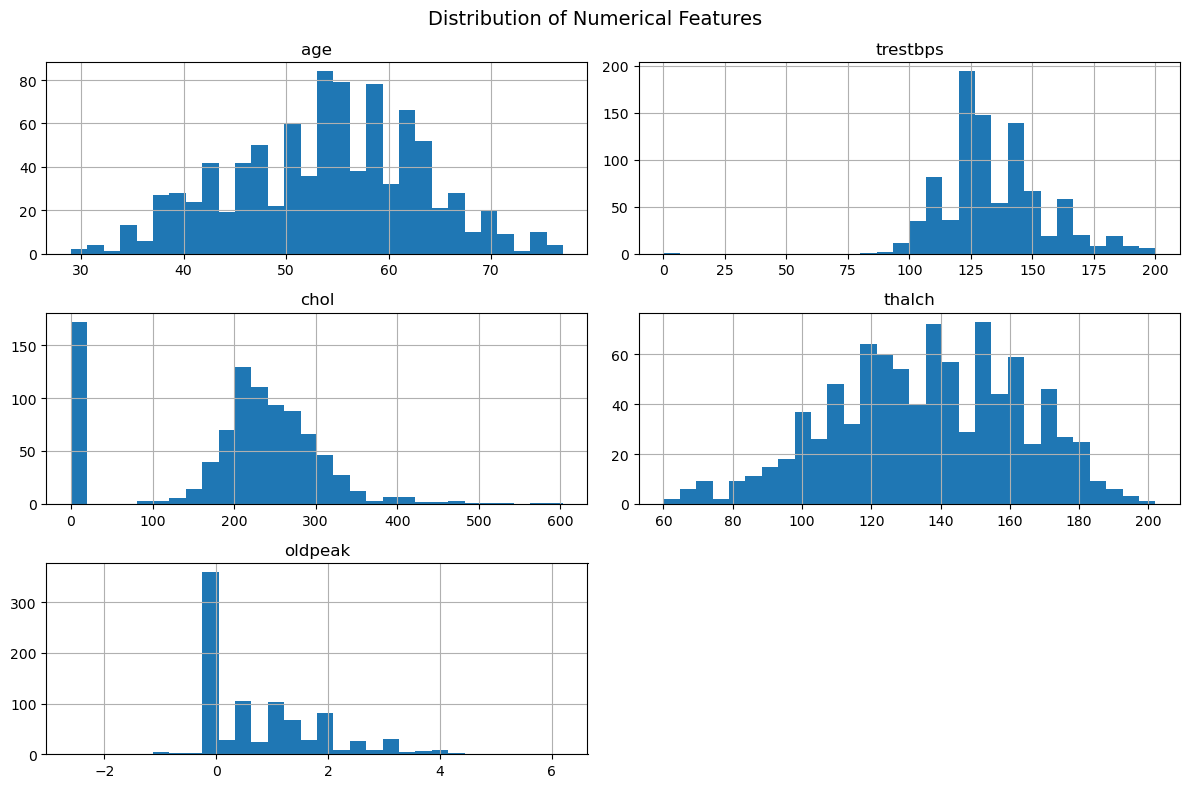

In [17]:
# Histograms of numerical features
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df[numerical_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=14)
plt.tight_layout()
plt.savefig('heart_histograms.png')
plt.show()

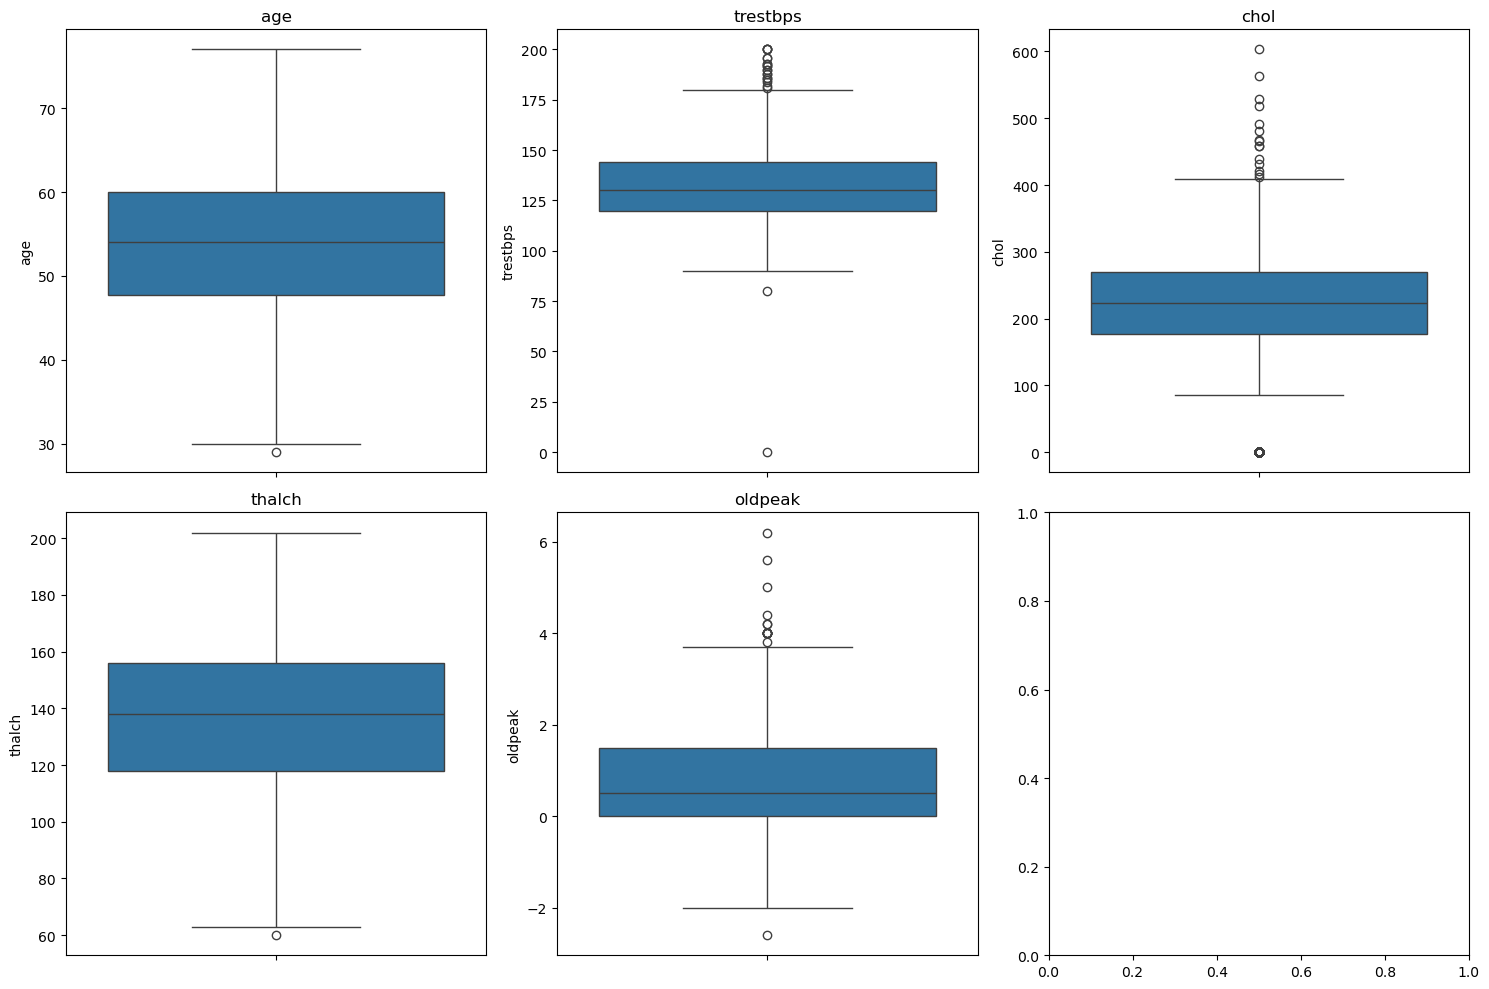

In [18]:
# Box plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('heart_boxplots.png')
plt.show()

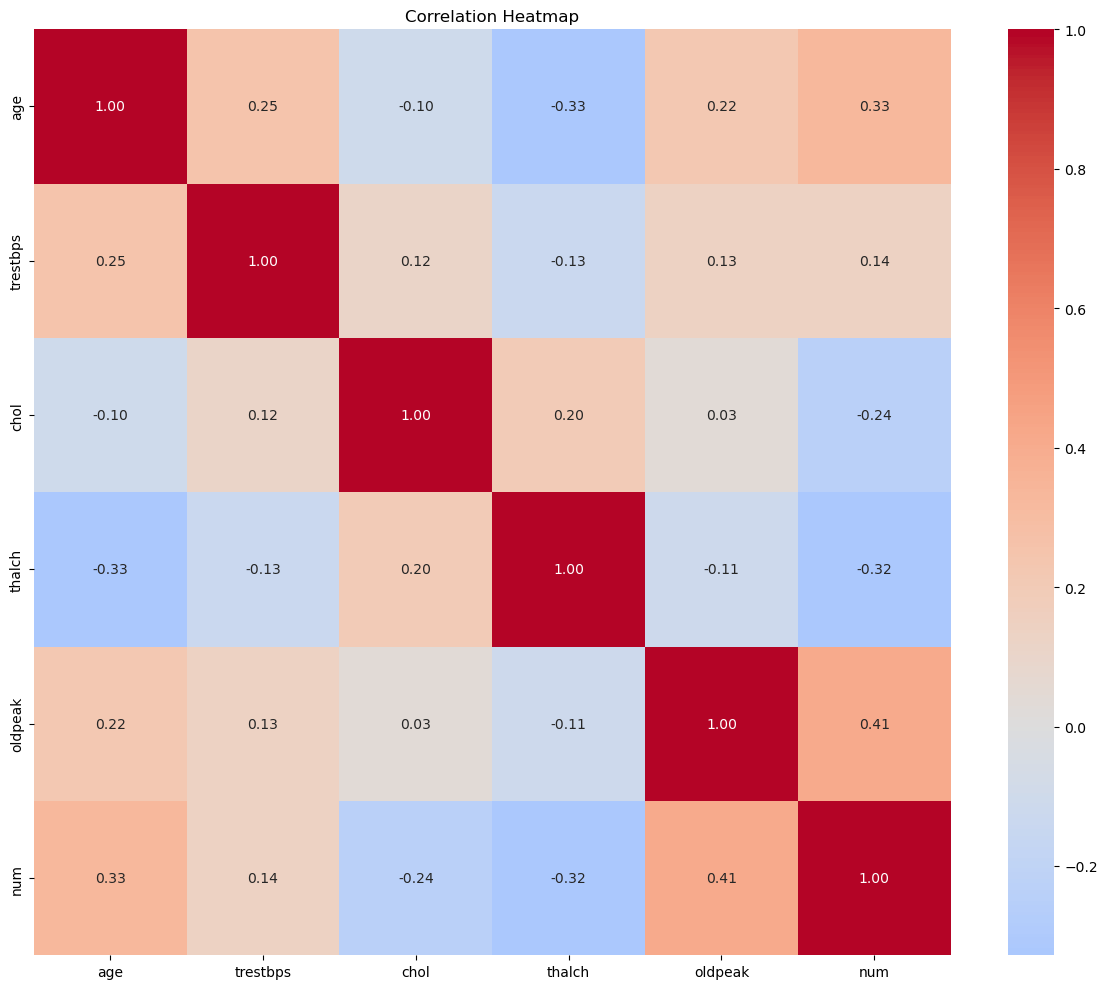

In [19]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation = df[numerical_cols + ['num']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('heart_correlation.png')
plt.show()


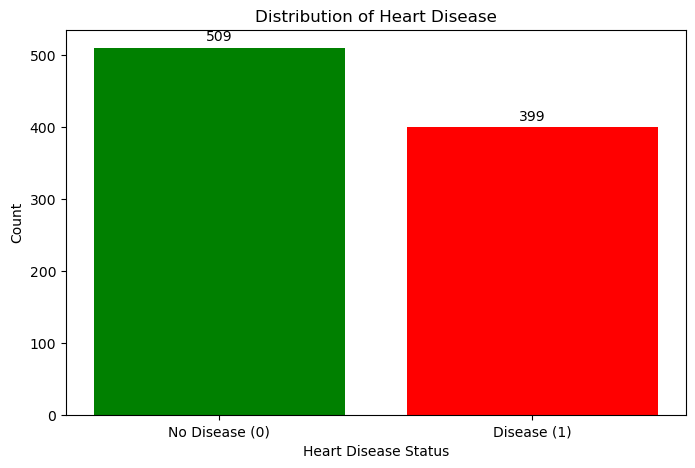

In [20]:
# Target distribution bar plot
plt.figure(figsize=(8, 5))
colors = ['green', 'red']
bars = plt.bar(['No Disease (0)', 'Disease (1)'], df['target'].value_counts(), color=colors)
plt.xlabel('Heart Disease Status')
plt.ylabel('Count')
plt.title('Distribution of Heart Disease')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(int(bar.get_height())), ha='center')
plt.savefig('target_distribution.png')
plt.show()

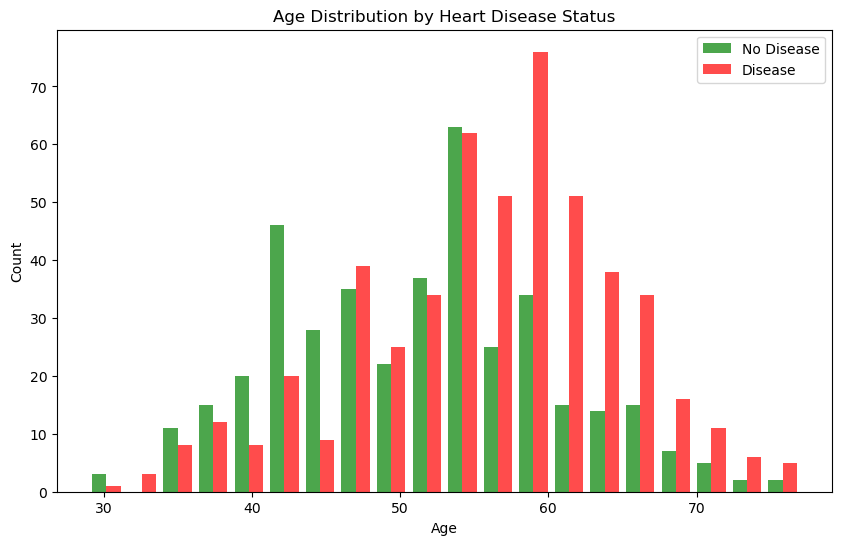

In [21]:
# Age distribution by target
plt.figure(figsize=(10, 6))
plt.hist([df[df['target']==0]['age'], df[df['target']==1]['age']], bins=20, label=['No Disease', 'Disease'], alpha=0.7, color=['green', 'red'])
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Heart Disease Status')
plt.legend()
plt.savefig('age_by_target.png')
plt.show()

In [22]:
# TASK 3: FEATURE ENGINEERING

In [23]:
# Identify categorical columns
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
print(f"Categorical columns: {categorical_cols}")


Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


In [24]:
# Apply Label Encoding to categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {df[col].nunique()} categories encoded")


sex: 2 categories encoded
cp: 4 categories encoded
fbs: 2 categories encoded
restecg: 3 categories encoded
exang: 1 categories encoded
slope: 3 categories encoded
thal: 3 categories encoded


In [26]:
# Select features for model
feature_cols = numerical_cols + [col + '_encoded' for col in categorical_cols]
X = df[feature_cols]
y = df['target']
print(f"\nFeatures selected: {feature_cols}")
print(f"Feature matrix shape: {X.shape}")



Features selected: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_encoded', 'cp_encoded', 'fbs_encoded', 'restecg_encoded', 'exang_encoded', 'slope_encoded', 'thal_encoded']
Feature matrix shape: (908, 12)


In [27]:
# Handle any remaining missing values
X = X.fillna(X.median())
print("Missing values handled with median imputation")

Missing values handled with median imputation


In [28]:
# TASK 4: DECISION TREE CLASSIFICATION

In [29]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training - Disease: {(y_train==1).sum()}, No Disease: {(y_train==0).sum()}")
print(f"Test - Disease: {(y_test==1).sum()}, No Disease: {(y_test==0).sum()}")



Training set size: (726, 12)
Test set size: (182, 12)
Training - Disease: 407, No Disease: 319
Test - Disease: 102, No Disease: 80


In [30]:
# Basic Decision Tree
dt_basic = DecisionTreeClassifier(random_state=42)
dt_basic.fit(X_train, y_train)
y_pred_basic = dt_basic.predict(X_test)
y_pred_proba_basic = dt_basic.predict_proba(X_test)[:, 1]

print("\nBasic Decision Tree Performance:")
print("-"*40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_basic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_basic):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_basic):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_basic):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_basic):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_basic, target_names=['No Disease', 'Disease']))



Basic Decision Tree Performance:
----------------------------------------
Accuracy:  0.7418
Precision: 0.7778
Recall:    0.7549
F1-Score:  0.7662
ROC-AUC:   0.7400

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71        80
     Disease       0.78      0.75      0.77       102

    accuracy                           0.74       182
   macro avg       0.74      0.74      0.74       182
weighted avg       0.74      0.74      0.74       182



In [31]:
# Confusion Matrix
cm_basic = confusion_matrix(y_test, y_pred_basic)
print("\nConfusion Matrix:")
print("               Predicted")
print("               No    Yes")
print(f"Actual No     {cm_basic[0,0]:3d}   {cm_basic[0,1]:3d}")
print(f"Actual Yes    {cm_basic[1,0]:3d}   {cm_basic[1,1]:3d}")



Confusion Matrix:
               Predicted
               No    Yes
Actual No      58    22
Actual Yes     25    77


In [32]:
# TASK 5: HYPERPARAMETER TUNING

In [33]:
# Define hyperparameters to tune
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

print("Hyperparameters being tuned:")
print("- max_depth: Controls tree depth (prevents overfitting)")
print("- min_samples_split: Minimum samples to split a node")
print("- min_samples_leaf: Minimum samples in leaf node")
print("- criterion: Split quality measure (gini or entropy)")


Hyperparameters being tuned:
- max_depth: Controls tree depth (prevents overfitting)
- min_samples_split: Minimum samples to split a node
- min_samples_leaf: Minimum samples in leaf node
- criterion: Split quality measure (gini or entropy)


In [34]:
# Grid search
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")



Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best Cross-Validation F1-Score: 0.7966


In [35]:
# Best model
dt_best = grid_search.best_estimator_
y_pred_best = dt_best.predict(X_test)
y_pred_proba_best = dt_best.predict_proba(X_test)[:, 1]

print("\nTuned Decision Tree Performance:")
print("-"*40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_best):.4f}")

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Disease']))



Tuned Decision Tree Performance:
----------------------------------------
Accuracy:  0.7418
Precision: 0.7723
Recall:    0.7647
F1-Score:  0.7685
ROC-AUC:   0.8100

Classification Report (Tuned Model):
              precision    recall  f1-score   support

  No Disease       0.70      0.71      0.71        80
     Disease       0.77      0.76      0.77       102

    accuracy                           0.74       182
   macro avg       0.74      0.74      0.74       182
weighted avg       0.74      0.74      0.74       182



In [36]:
# Confusion Matrix for tuned model
cm_best = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix (Tuned Model):")
print("               Predicted")
print("               No    Yes")
print(f"Actual No     {cm_best[0,0]:3d}   {cm_best[0,1]:3d}")
print(f"Actual Yes    {cm_best[1,0]:3d}   {cm_best[1,1]:3d}")



Confusion Matrix (Tuned Model):
               Predicted
               No    Yes
Actual No      57    23
Actual Yes     24    78


In [37]:
# TASK 6: MODEL EVALUATION AND ANALYSIS

In [38]:
# Comparison table
print("\nModel Performance Comparison:")
print("-"*50)
print(f"{'Metric':<15} {'Basic DT':<12} {'Tuned DT':<12}")
print("-"*50)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred_basic):.4f}         {accuracy_score(y_test, y_pred_best):.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred_basic):.4f}         {precision_score(y_test, y_pred_best):.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred_basic):.4f}         {recall_score(y_test, y_pred_best):.4f}")
print(f"{'F1-Score':<15} {f1_score(y_test, y_pred_basic):.4f}         {f1_score(y_test, y_pred_best):.4f}")
print(f"{'ROC-AUC':<15} {roc_auc_score(y_test, y_pred_proba_basic):.4f}         {roc_auc_score(y_test, y_pred_proba_best):.4f}")



Model Performance Comparison:
--------------------------------------------------
Metric          Basic DT     Tuned DT    
--------------------------------------------------
Accuracy        0.7418         0.7418
Precision       0.7778         0.7723
Recall          0.7549         0.7647
F1-Score        0.7662         0.7685
ROC-AUC         0.7400         0.8100


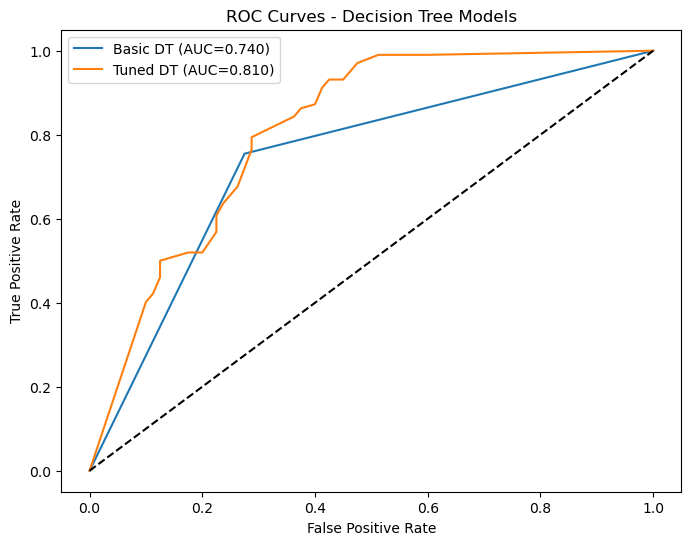

In [39]:
# ROC Curve
plt.figure(figsize=(8, 6))
fpr_basic, tpr_basic, _ = roc_curve(y_test, y_pred_proba_basic)
fpr_best, tpr_best, _ = roc_curve(y_test, y_pred_proba_best)
plt.plot(fpr_basic, tpr_basic, label=f'Basic DT (AUC={roc_auc_score(y_test, y_pred_proba_basic):.3f})')
plt.plot(fpr_best, tpr_best, label=f'Tuned DT (AUC={roc_auc_score(y_test, y_pred_proba_best):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Decision Tree Models')
plt.legend()
plt.savefig('roc_curves.png')
plt.show()


Feature Importance (Top 10):
          Feature  Importance
6      cp_encoded    0.450508
2            chol    0.170139
4         oldpeak    0.104112
3          thalch    0.074782
0             age    0.074077
5     sex_encoded    0.049407
11   thal_encoded    0.029248
1        trestbps    0.023598
7     fbs_encoded    0.020873
10  slope_encoded    0.003256


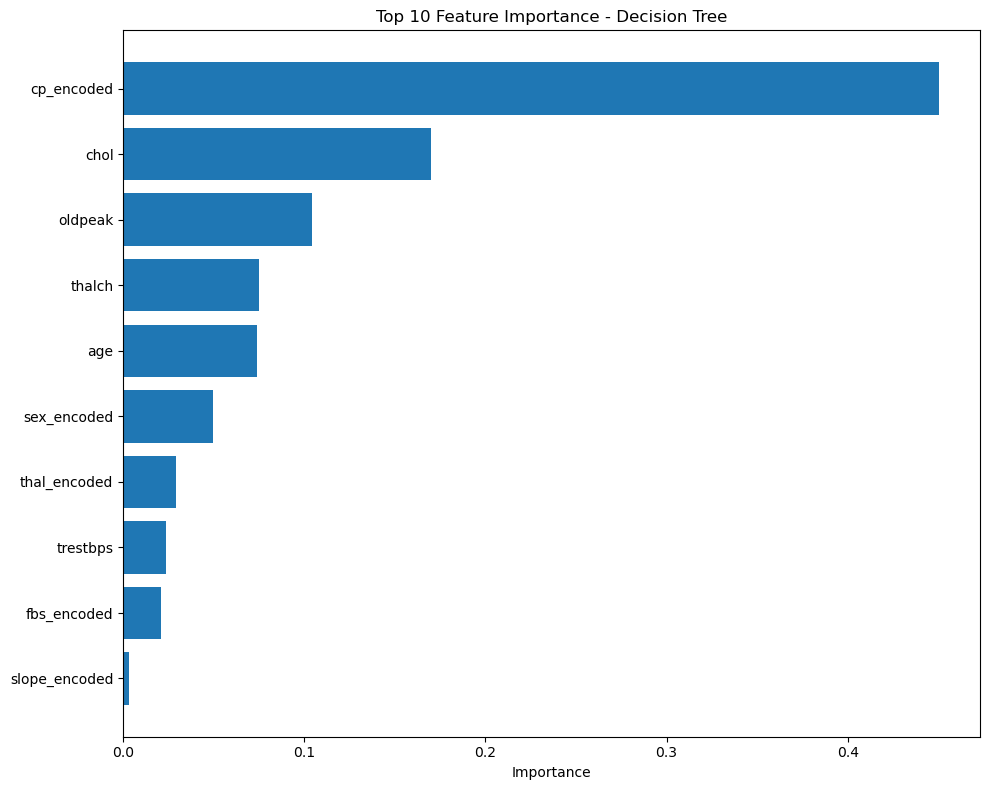

In [40]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Top 10):")
print(feature_importance.head(10))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

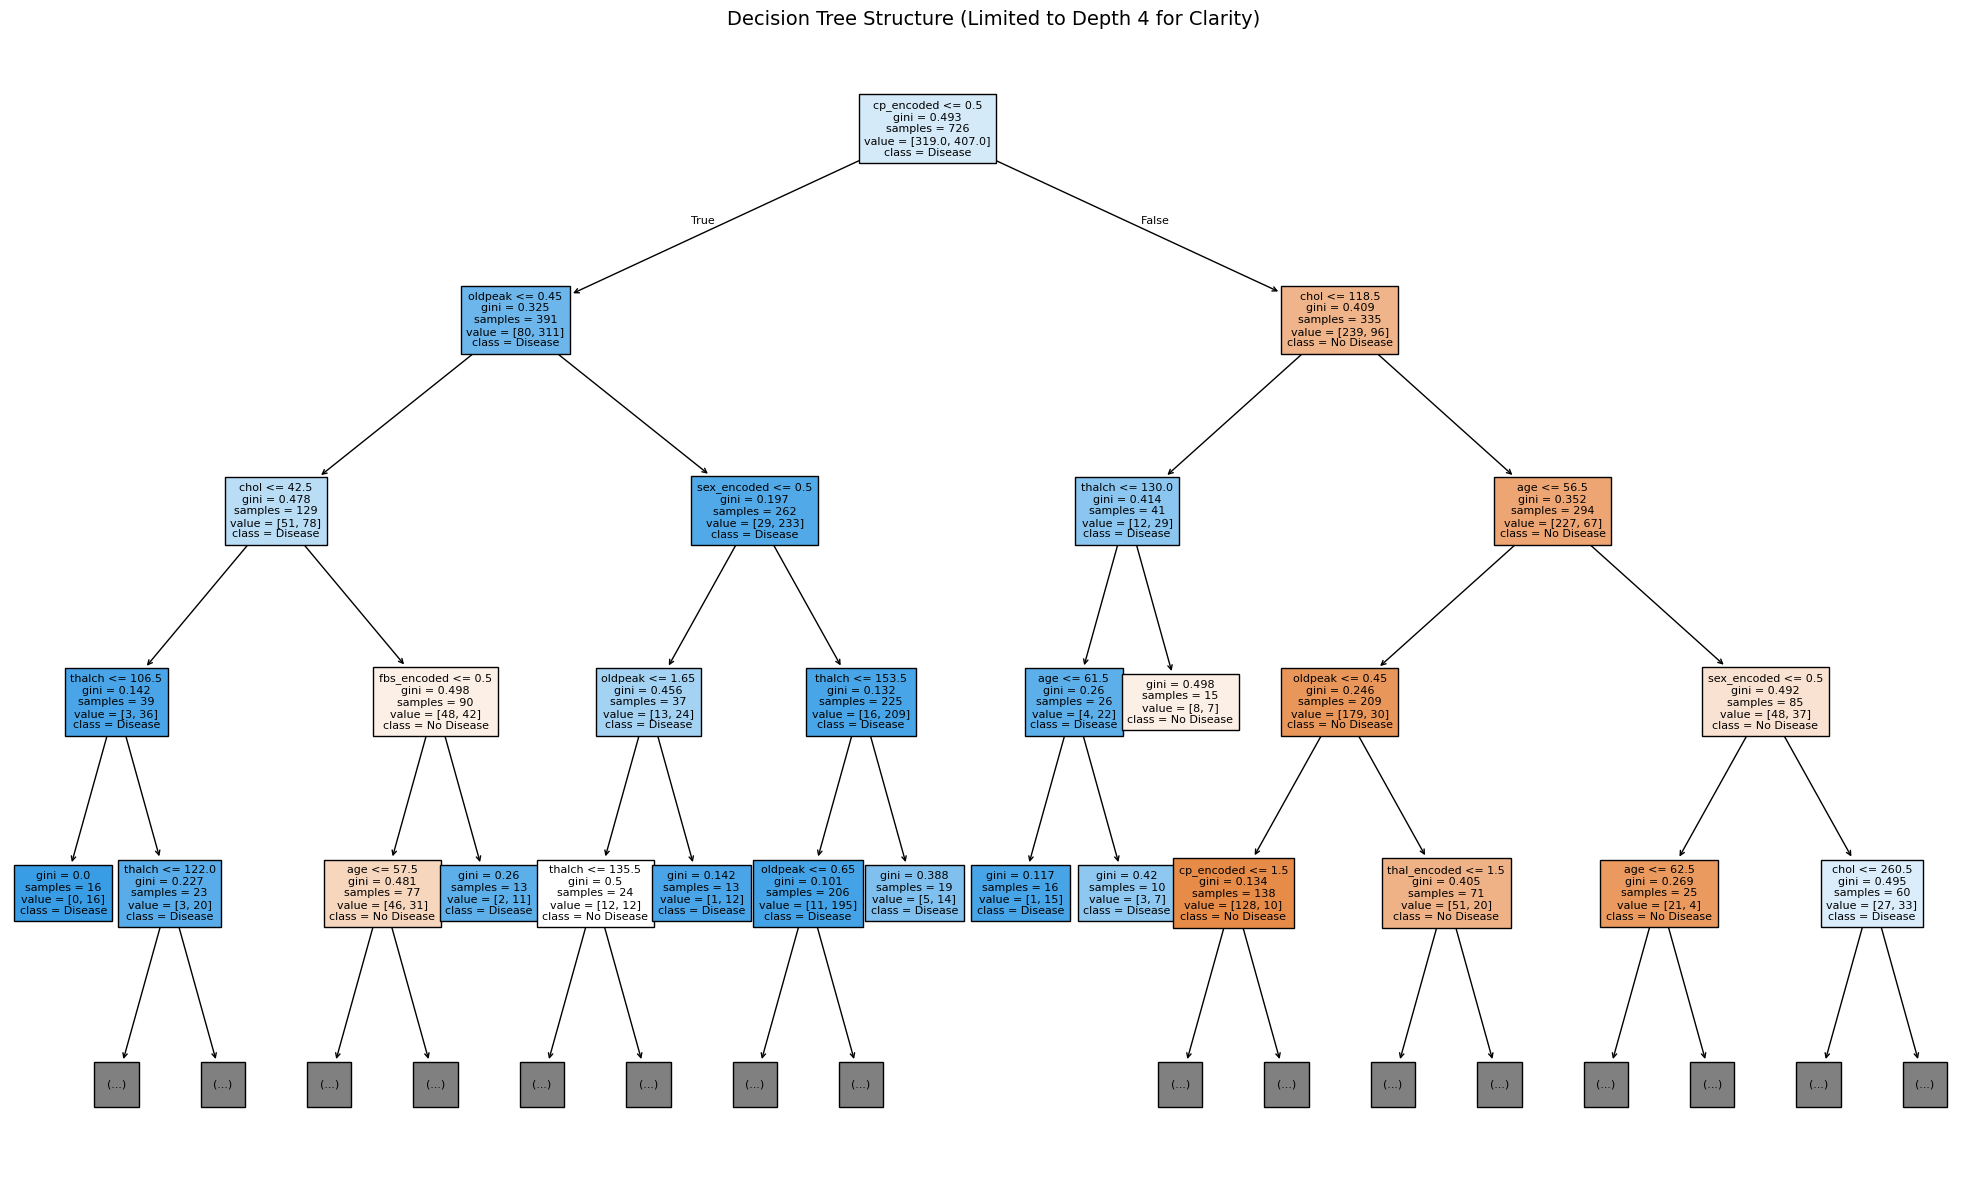

In [41]:
# Visualize Decision Tree
plt.figure(figsize=(20, 12))
plot_tree(dt_best, feature_names=feature_cols, class_names=['No Disease', 'Disease'], filled=True, max_depth=4, fontsize=8)
plt.title('Decision Tree Structure (Limited to Depth 4 for Clarity)', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()

In [42]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"Best Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best F1-Score: 0.7685
Best Accuracy: 0.7418


In [44]:
print("INTERVIEW QUESTIONS ANSWERS")


print("\n1. COMMON HYPERPARAMETERS OF DECISION TREE MODELS:")

print("a) max_depth:")
print("   - Maximum depth of the tree")
print("   - Effect: Smaller depth = simpler model (less overfitting)")
print("   - Effect: Larger depth = more complex model (may overfit)")

print("\nb) min_samples_split:")
print("   - Minimum samples required to split a node")
print("   - Effect: Higher value = stops earlier (more pruning)")
print("   - Effect: Lower value = more splits (more complex)")

print("\nc) min_samples_leaf:")
print("   - Minimum samples required in a leaf node")
print("   - Effect: Higher value = smoother boundaries (less overfitting)")

print("\nd) criterion:")
print("   - Function to measure split quality (gini or entropy)")
print("   - Gini: Gini impurity (default, faster)")
print("   - Entropy: Information gain (slower, similar results)")

print("\ne) max_features:")
print("   - Number of features to consider for best split")
print("   - Effect: Lower value = more randomness, reduces overfitting")

print("\nf) max_leaf_nodes:")
print("   - Maximum number of leaf nodes")
print("   - Effect: Limits tree complexity, prevents overfitting")

print("\n2. LABEL ENCODING VS ONE-HOT ENCODING:")

print("LABEL ENCODING:")
print("   - Converts categories to numbers (0, 1, 2, 3...)")
print("   - Example: ['Red','Blue','Green'] -> [0,1,2]")
print("   - Pros: Memory efficient, single column")
print("   - Cons: Implies ordinal relationship (0<1<2)")
print("   - Best for: Ordinal data (Low, Medium, High)")

print("\nONE-HOT ENCODING:")
print("   - Creates binary columns for each category")
print("   - Example: ['Red','Blue','Green'] -> [1,0,0],[0,1,0],[0,0,1]")
print("   - Pros: No ordinal assumption, treats categories equally")
print("   - Cons: Creates many columns (curse of dimensionality)")
print("   - Best for: Nominal data (colors, countries)")


INTERVIEW QUESTIONS ANSWERS

1. COMMON HYPERPARAMETERS OF DECISION TREE MODELS:
a) max_depth:
   - Maximum depth of the tree
   - Effect: Smaller depth = simpler model (less overfitting)
   - Effect: Larger depth = more complex model (may overfit)

b) min_samples_split:
   - Minimum samples required to split a node
   - Effect: Higher value = stops earlier (more pruning)
   - Effect: Lower value = more splits (more complex)

c) min_samples_leaf:
   - Minimum samples required in a leaf node
   - Effect: Higher value = smoother boundaries (less overfitting)

d) criterion:
   - Function to measure split quality (gini or entropy)
   - Gini: Gini impurity (default, faster)
   - Entropy: Information gain (slower, similar results)

e) max_features:
   - Number of features to consider for best split
   - Effect: Lower value = more randomness, reduces overfitting

f) max_leaf_nodes:
   - Maximum number of leaf nodes
   - Effect: Limits tree complexity, prevents overfitting

2. LABEL ENCODING VS